Dataset → Cleaning → Sentiment Label → Text Preprocessing
→ TF-IDF Vectorization → Model Training → Evaluation
→ Save Model → Flask Web App


sklearn --	machine learning;
nltk--	natural language processing;
flask --	web application;

In [3]:
import pandas as pd
import numpy as np
import sklearn as sk
import nltk
import flask

In [7]:
import pandas as pd
data =pd.read_csv(r"C:\Users\HP\Desktop\Data sciencee\bigprojects\flipcart\Dataset\Dataset.csv",encoding="latin1")
print(data.head())
print(data.columns)

                                        Product_name      Price Rate  \
0  Crompton 75 L Desert Air Cooler??(White, Tea...  ??10,499    5   
1  Crompton 75 L Desert Air Cooler??(White, Tea...  ??10,499    4   
2  Crompton 75 L Desert Air Cooler??(White, Tea...  ??10,499    5   
3  Crompton 75 L Desert Air Cooler??(White, Tea...  ??10,499    5   
4  Crompton 75 L Desert Air Cooler??(White, Tea...  ??10,499    4   

                                              Review  \
0                                     Simply awesome   
1  Worth the money . Desert Cooler live up to the...   
2                                  Worth every penny   
3                                          Fabulous!   
4                                       Nice product   

                                             Summary  
0  it's really worth every single penny. it works...  
1  I bought Crompton Ozone 75 Desert Air Cooler i...  
2  GREAT packaging by seller. As this was the mos...  
3  Deliver

C:\Users\HP\AppData\Local\Temp\ipykernel_18988\2141262971.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data =pd.read_csv(r"C:\Users\HP\Desktop\Data sciencee\bigprojects\flipcart\Dataset\Dataset.csv",encoding="latin1")


encoding="latin1" → handles special characters
low_memory=False → prevents datatype warnings


In [8]:
import pandas as pd

data = pd.read_csv(
r"C:\Users\HP\Desktop\Data sciencee\bigprojects\flipcart\Dataset\Dataset.csv",
encoding="latin1",
low_memory=False
)

print(data.head())


                                        Product_name      Price Rate  \
0  Crompton 75 L Desert Air Cooler??(White, Tea...  ??10,499    5   
1  Crompton 75 L Desert Air Cooler??(White, Tea...  ??10,499    4   
2  Crompton 75 L Desert Air Cooler??(White, Tea...  ??10,499    5   
3  Crompton 75 L Desert Air Cooler??(White, Tea...  ??10,499    5   
4  Crompton 75 L Desert Air Cooler??(White, Tea...  ??10,499    4   

                                              Review  \
0                                     Simply awesome   
1  Worth the money . Desert Cooler live up to the...   
2                                  Worth every penny   
3                                          Fabulous!   
4                                       Nice product   

                                             Summary  
0  it's really worth every single penny. it works...  
1  I bought Crompton Ozone 75 Desert Air Cooler i...  
2  GREAT packaging by seller. As this was the mos...  
3  Deliver

Explanation:-

This removes weird characters from product names.

Example:-
         Before:
Crompton Cooler ??

After:
Crompton Cooler


In [9]:
data["Product_name"] = data["Product_name"].str.replace(r"[^\x00-\x7F]+", "", regex=True)


Removes currency symbols and converts price to numbers.
Example:-
         Before:
         ₹1,299.00
After:
1299.00

In [11]:
data["Price"] = data["Price"].str.replace(r"[^\d]", "", regex=True)

data["Price"] = pd.to_numeric(data["Price"], errors="coerce")


Removes rows where price is missing.

In [12]:
data = data.dropna(subset=["Price"])


In [13]:
data["Price"] = data["Price"].astype(int)


In [15]:
print(data.columns)


Index(['Product_name', 'Price', 'Rate', 'Review', 'Summary'], dtype='object')


In [17]:
print(data["Rate"].unique()[:20])


['5' '4' '3' '1' '2'
 'Pigeon Favourite Electric Kettle????(1.5 L, Silver, Black)'
 'Bajaj DX 2 L/W Dry Iron'
 'Nova Plus Amaze NI 10 1100 W Dry Iron????(Grey & Turquoise)']


changing datatype of price to number

In [18]:
data["Rate"] = pd.to_numeric(data["Rate"], errors="coerce")


Removes rows where rate is missing.

In [19]:
data = data.dropna(subset=["Rate"])


In [20]:
data["Rate"] = data["Rate"].astype(int)


Explanation:-

This converts rating → sentiment.

Rating	Sentiment
4–5	  ==  Positive;
3 ==	Neutral;
1–2	 ==  Negative;

In [21]:
def sentiment_label(rate):

    if rate >= 4:
        return "Positive"

    elif rate == 3:
        return "Neutral"

    else:
        return "Negative"


data["Sentiment"] = data["Rate"].apply(sentiment_label)

print(data[["Rate","Sentiment"]].head())


   Rate Sentiment
0     5  Positive
1     4  Positive
2     5  Positive
3     5  Positive
4     4  Positive


Explanation:-

Combines review + summary.

Review: Nice product
Summary: Works well

Final Text:
"Nice product Works well"


In [22]:
data["text"] = data["Review"] + " " + data["Summary"]

print(data["text"].head())


0    Simply awesome it's really worth every single ...
1    Worth the money . Desert Cooler live up to the...
2    Worth every penny GREAT packaging by seller. A...
3    Fabulous! Delivery was delayed by two days exc...
4    Nice product A Good cooler by Crompton. The he...
Name: text, dtype: object


Import nlp tools

In [23]:
import nltk
import re
from nltk.corpus import stopwords


In [24]:
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

Create Stopword List:=
Stopwords are common words like:
the
is
and
was


In [25]:
stop_words = set(stopwords.words("english"))


In [26]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

Text Cleaning Function:-
Explanation:-
1 Convert to lowercase
2 Remove special characters
3 Split words
4 Remove stopwords
5 Join words


Input:
"This product is very good!!!"

Output:
"product good"


In [27]:
def clean_text(text):

    text = text.lower()

    text = re.sub("[^a-zA-Z]", " ", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)


Now the dataset contains clean text for ML.

In [29]:
data["text"] = data["text"].fillna("")


In [30]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub("[^a-zA-Z]", " ", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)


In [31]:
data["clean_text"] = data["text"].apply(clean_text)

print(data["clean_text"].head())


0    simply awesome really worth every single penny...
1    worth money desert cooler live name bought cro...
2    worth every penny great packaging seller impor...
3    fabulous delivery delayed two days except ever...
4    nice product good cooler crompton height coole...
Name: clean_text, dtype: object


In [32]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub("[^a-zA-Z]", " ", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

data["clean_text"] = data["text"].apply(clean_text)

print(data["clean_text"].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    simply awesome really worth every single penny...
1    worth money desert cooler live name bought cro...
2    worth every penny great packaging seller impor...
3    fabulous delivery delayed two days except ever...
4    nice product good cooler crompton height coole...
Name: clean_text, dtype: object


TF-IDF Vectorization:-
Explanation

Machine learning cannot understand text.

So text → numbers.

Example:-
"good product" → [0.45, 0.32, 0.12...]


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(data["clean_text"])

y = data["Sentiment"]


Train Test Split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Train Machine Learning Model:-
Explanation

We use Naive Bayes algorithm for text classification.

why?

Fast
Works well with text
Simple


In [35]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Evaluate model and find accuracy


In [36]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))


Accuracy: 0.9342170465807731


In [37]:
review = ["This product is amazing and works perfectly"]

review_vec = vectorizer.transform(review)

prediction = model.predict(review_vec)

print(prediction)


['Positive']


Visualization:-This creates a sentiment bar chart.




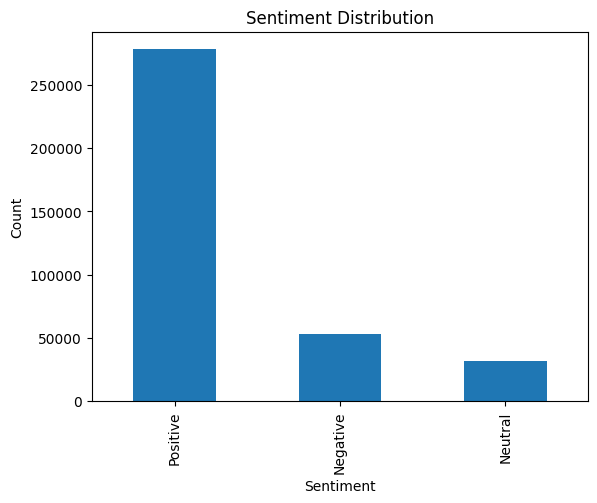

In [38]:
import matplotlib.pyplot as plt

data["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()


Dataset
   ↓
Data Cleaning
   ↓
Create Sentiment Labels
   ↓
Combine Review + Summary
   ↓
Text Preprocessing
   ↓
TF-IDF Vectorization
   ↓
Train Model
   ↓
Test Accuracy
   ↓
Prediction
   ↓
Visualization


Confusion Matrix:-
This shows how predictions are distributed.

In [39]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, pred)

print(cm)


[[ 9661    46   955]
 [  393  2908  3050]
 [  212   123 55300]]


In [40]:
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

    Negative       0.94      0.91      0.92     10662
     Neutral       0.95      0.46      0.62      6351
    Positive       0.93      0.99      0.96     55635

    accuracy                           0.93     72648
   macro avg       0.94      0.79      0.83     72648
weighted avg       0.93      0.93      0.93     72648



In [45]:
import pickle

pickle.dump(model, open("sentiment_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))


Test Prediction

In [42]:
review = ["This product is very bad and waste of money"]

review_vec = vectorizer.transform(review)

prediction = model.predict(review_vec)

print("Predicted Sentiment:", prediction[0])


Predicted Sentiment: Negative


#Complete Project Flow

Dataset
   ↓
Cleaning
   ↓
Sentiment Labeling
   ↓
Text Preprocessing
   ↓
TF-IDF Vectorization
   ↓
Naive Bayes Model
   ↓
Evaluation
   ↓
Save Model
   ↓
Flask Web App
